In [1]:
import sys
sys.path.append('..')  # Add parent directory to path

from denoising import DenoisingPipeline
from denoising.config import load_config
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nibabel as nib
import numpy as np

from denoising.io.file_handler import BIDSFileLoader
from denoising.config.schemas import BIDSConfig

from nilearn.maskers import NiftiLabelsMasker, NiftiMasker   

sns.set_style('whitegrid')

# DATA

In [4]:
# DATA 

stress_data_path = '/data/Projects/STRESS_DATA/bids_stress/derivatives'
control_data_path = '/data/Projects/STRESS_DATA/bids_control/derivatives'

stress_bids_loader = BIDSFileLoader(stress_data_path)
control_bids_loader = BIDSFileLoader(control_data_path)

In [36]:
stress_bids_loader.get_subject_img(subject='all')

[]

In [5]:
stress_bids_loader.get_subject_mask(subject='09', space='MNI152NLin2009cAsym')

['/data/Projects/STRESS_DATA/bids_stress/derivatives/sub-09/func/sub-09_task-rest_space-MNI152NLin2009cAsym_desc-brain_mask.nii.gz']

In [7]:
bids_layout = stress_bids_loader.layout

# mean mask

In [ ]:
stress_data_path = '/data/Projects/STRESS_DATA/bids_stress/derivatives'
control_data_path = '/data/Projects/STRESS_DATA/bids_control/derivatives'

stress_bids_loader = BIDSFileLoader(stress_data_path)
control_bids_loader = BIDSFileLoader(control_data_path)

In [28]:
img = stress_bids_loader.get_subject_img(subject=['09', '10'], space='MNI152NLin2009cAsym')

In [67]:
img

['/data/Projects/STRESS_DATA/bids_stress/derivatives/sub-02/func/sub-02_task-rest_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz']

In [ ]:
mask = stress_bids_loader.get_subject_mask(subject=['09', '10'], space='MNI152NLin2009cAsym')
m1 = nib.load(mask[0])
m2 = nib.load(mask[1])

In [69]:
nib.load(img[0]).header.get_zooms()[-1]

np.float32(0.96)

In [15]:
t = (m1.get_fdata() + m2.get_fdata()) / 2

In [16]:
t.shape

(93, 116, 60)

In [20]:

atlas_img = nib.load('/home/tm/nilearn_data/brainnetome/BN_Atlas_246_2mm.nii.gz')
#masker_labels = atlas.atlas_labels


# все что не ноль то один
# создаем бинарный атлас, чтобы потом считтать воксели
atlas_img_bin = nib.Nifti1Image(
    (atlas_img.get_fdata() > 0).astype(np.uint8), 
    atlas_img.affine, 
    atlas_img.header,)


sum_masker_masked = NiftiLabelsMasker(
                        labels_img=atlas_img,
                        #labels=masker_labels,
                        background_label=0,
                        mask_img=mask[0], # средняя маска
                        smoothing_fwhm=None,
                        standardize=False,
                        strategy="sum",
                        resampling_target='data',  # !!!!!!!!!!!!!!!!!!!! check resampling 
                        )

# no mask image here !!
sum_masker_unmasked = NiftiLabelsMasker(
                        labels_img=atlas_img,
                        #labels=masker_labels,
                        background_label=0,
                        smoothing_fwhm=None,
                        standardize=False,
                        strategy="sum", # sum to see number of 
                        resampling_target='data',
                        )


# вместо мозга передаем бинаризованый атлас, 
# и считаем сколько вокселей попадает в маску (суммируем количество вокселей в рои)
n_voxels_in_masked_parcels = sum_masker_masked.fit_transform(atlas_img_bin)
# считаем сколько всего вокселей в рои в атласе
n_voxels_in_parcels = sum_masker_unmasked.fit_transform(atlas_img_bin)
# процент вокселей в маске
parcel_coverage = np.squeeze(n_voxels_in_masked_parcels / n_voxels_in_parcels)

(array([  2.,   0.,   1.,   3.,   2.,   9.,   4.,   6.,   7., 212.]),
 array([0.56989247, 0.61290323, 0.65591398, 0.69892473, 0.74193548,
        0.78494624, 0.82795699, 0.87096774, 0.91397849, 0.95698925,
        1.        ]),
 <BarContainer object of 10 artists>)

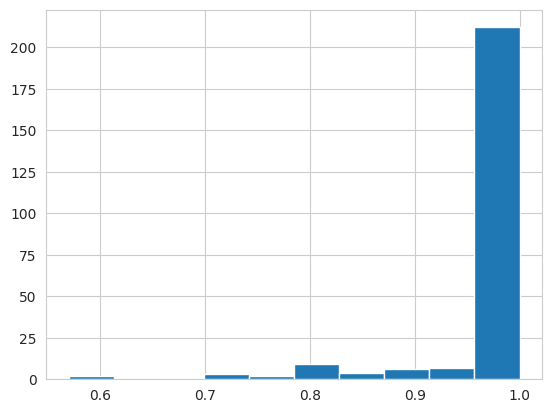

In [22]:
plt.hist(parcel_coverage)

# config 

In [24]:
config = load_config('../configs/strategy_4.yaml')

print(f"Atlas: {config.atlas.name} with {config.atlas.n_regions} regions")
print(f"Smoothing FWHM: {config.denoising.smoothing_fwhm} mm")
print(f"Standardization: {config.denoising.standardize}")
print(f"Standardization OF CONFOUNDS: {config.denoising.standardize_confounds}")

Atlas: schaefer_2018 with 400 regions
Smoothing FWHM: 4.0 mm
Standardization: None
Standardization OF CONFOUNDS: True


In [25]:
pipeline = DenoisingPipeline(config)
print("Pipeline initialized successfully")

Pipeline initialized successfully


In [ ]:
confounds, sample_mask = pipeline.confounds_handler.load_and_select(img[0])

In [73]:
confounds

,a_comp_cor_00,a_comp_cor_01,a_comp_cor_02,a_comp_cor_03,a_comp_cor_04,a_comp_cor_05,a_comp_cor_06,a_comp_cor_07,a_comp_cor_08,a_comp_cor_09,...,trans_x_derivative1_power2,trans_x_power2,trans_y,trans_y_derivative1,trans_y_derivative1_power2,trans_y_power2,trans_z,trans_z_derivative1,trans_z_derivative1_power2,trans_z_power2
0,6.711409e-13,1.510067e-12,-5.033554e-13,-6.711412e-13,-2.348993e-12,-1.845638e-12,0.000000,3.355709e-13,6.711411e-13,1.677849e-13,...,-0.000115,-0.004234,-0.103391,0.011280,-0.001002,-0.016972,0.264133,-0.129246,0.015768,-0.062741
1,6.711409e-13,1.510067e-12,-5.033554e-13,-6.711412e-13,-2.348993e-12,-1.845638e-12,0.000000,3.355709e-13,6.711411e-13,1.677849e-13,...,-0.000115,-0.004234,-0.091808,0.011280,-0.001002,-0.016469,0.134282,-0.129246,0.015768,-0.056704
2,6.711409e-13,1.510067e-12,-5.033554e-13,-6.711412e-13,-2.348993e-12,-1.845638e-12,0.000000,3.355709e-13,6.711411e-13,1.677849e-13,...,-0.000115,-0.004234,-0.104530,-0.013026,-0.000975,-0.017007,0.126203,-0.007473,-0.001028,-0.055214
3,6.711409e-13,1.510067e-12,-5.033554e-13,-6.711412e-13,-2.348993e-12,-1.845638e-12,0.000000,3.355709e-13,6.711411e-13,1.677849e-13,...,-0.000086,-0.004204,-0.109103,-0.004876,-0.001116,-0.017121,0.142844,0.017246,-0.000817,-0.058140
4,-2.389412e-02,-3.479936e-02,2.528825e-02,-5.933268e-02,-2.891486e-02,3.917873e-02,-0.085035,2.283400e-02,-1.003446e-01,4.447624e-02,...,0.000062,-0.004172,-0.109249,-0.000449,-0.001136,-0.017124,0.147872,0.005633,-0.001068,-0.058916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,1.794922e-02,1.352951e-02,-3.648714e-02,5.033269e-02,-6.827722e-02,2.718702e-02,-0.063423,1.953215e-03,-2.927259e-02,-8.501483e-02,...,-0.000112,0.025790,0.026429,0.000259,-0.001136,0.004016,-0.237265,-0.003919,-0.001073,0.146862
596,-4.314272e-02,-2.602911e-02,-2.382829e-02,1.087311e-02,-1.006979e-01,5.884984e-02,-0.064023,9.932353e-03,-6.468806e-02,-1.022627e-01,...,-0.000106,0.026888,0.026753,0.000021,-0.001136,0.004111,-0.225741,0.012130,-0.000961,0.136399
597,-6.176054e-02,-1.623082e-02,-3.370795e-02,5.683014e-02,-7.923566e-02,5.564767e-02,-0.018654,2.280681e-03,-1.258195e-01,-2.857201e-03,...,-0.000115,0.027104,0.027852,0.000796,-0.001135,0.004433,-0.226110,0.000236,-0.001094,0.136731
598,-1.231749e-02,9.629312e-03,-7.421020e-02,9.558981e-02,-4.887989e-02,8.557183e-02,-0.029981,5.075741e-02,-1.335627e-02,-2.621033e-02,...,-0.000115,0.026803,0.075833,0.047677,0.001166,0.020858,-0.225158,0.001557,-0.001093,0.135878


In [37]:
masker = NiftiLabelsMasker(
    labels_img=atlas_img,
    #labels=masker_labels,
    background_label=0,
    mask_img=mask, # средняя маска
    smoothing_fwhm=4,
    standardize=False,
    strategy="mean",
    resampling_target='data',  # !!!!!!!!!!!!!!!!!!!! check resampling 
    )



In [ ]:
sub_list = stress_bids_loader.get_all_subjects()
labels = pd.read_csv('/home/tm/nilearn_data/brainnetome/BN_Atlas_246_Label.txt', sep=' ', header=None)

In [76]:
from tqdm.notebook import tqdm

ts = []

for i in tqdm(control_bids_loader.get_all_subjects()):
    img = control_bids_loader.get_subject_img(subject=i, space='MNI152NLin2009cAsym')
    mask = control_bids_loader.get_subject_mask(subject=i, space='MNI152NLin2009cAsym')
    confounds, sample_mask = pipeline.confounds_handler.load_and_select(img[0])

    masker = NiftiLabelsMasker(
        labels_img=atlas_img,
        #labels=labels,
        background_label=0,
        mask_img=mask[0],
        smoothing_fwhm=4,
        standardize='zscore_sample',
        standardize_confounds=True,
        low_pass=0.08,
        t_r=0.96,
        strategy="mean",
        resampling_target='data',  # !!!!!!!!!!!!!!!!!!!! check resampling 
    )

    data = masker.fit_transform(img[0], confounds=confounds, sample_mask=sample_mask)

    ts.append(data)
    pd.DataFrame(columns=labels[1][1:], data=data).to_csv(f'/home/tm/projects/Denoising/output/control/ts_control_{i}.csv', index=False)



  0%|          | 0/20 [00:00<?, ?it/s]

/tmp/ipykernel_3825843/2903255836.py:24: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  data = masker.fit_transform(img[0], confounds=confounds, sample_mask=sample_mask)
/tmp/ipykernel_3825843/2903255836.py:24: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  data = masker.fit_transform(img[0], confounds=confounds, sample_mask=sample_mask)
/tmp/ipykernel_3825843/2903255836.py:24: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  data = masker.fit_transform(img[0], confounds=confounds, sample_mask=sample_mask)
/tmp/ipykernel_3825843/2903255836.py:24: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  data = masker.fit_transform(img[0], confounds=confounds, sample_mask=sample_mask)
/tmp

In [74]:
from tqdm.notebook import tqdm

ts = []

for i in tqdm(sub_list):
    img = stress_bids_loader.get_subject_img(subject=i, space='MNI152NLin2009cAsym')
    mask = stress_bids_loader.get_subject_mask(subject=i, space='MNI152NLin2009cAsym')
    confounds, sample_mask = pipeline.confounds_handler.load_and_select(img[0])

    masker = NiftiLabelsMasker(
        labels_img=atlas_img,
        #labels=labels,
        background_label=0,
        mask_img=mask[0],
        smoothing_fwhm=4,
        standardize='zscore_sample',
        standardize_confounds=True,
        low_pass=0.08,
        t_r=0.96,
        strategy="mean",
        resampling_target='data',  # !!!!!!!!!!!!!!!!!!!! check resampling 
    )

    data = masker.fit_transform(img[0], confounds=confounds, sample_mask=sample_mask)

    ts.append(data)
    pd.DataFrame(columns=labels[1][1:], data=data).to_csv(f'/home/tm/projects/Denoising/output/stress/ts_stress_{i}.csv', index=False)



  0%|          | 0/39 [00:00<?, ?it/s]

/tmp/ipykernel_3825843/4024889218.py:24: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  data = masker.fit_transform(img[0], confounds=confounds, sample_mask=sample_mask)
/tmp/ipykernel_3825843/4024889218.py:24: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  data = masker.fit_transform(img[0], confounds=confounds, sample_mask=sample_mask)
/tmp/ipykernel_3825843/4024889218.py:24: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  data = masker.fit_transform(img[0], confounds=confounds, sample_mask=sample_mask)
/tmp/ipykernel_3825843/4024889218.py:24: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  data = masker.fit_transform(img[0], confounds=confounds, sample_mask=sample_mask)
/tmp

In [72]:
pd.read_csv('/home/tm/projects/Denoising/notebooks/ts_stress_02.csv')

,A8m_L,A8m_R,A8dl_L,A8dl_R,A9l_L,A9l_R,A6dl_L,A6dl_R,A6m_L,A6m_R,...,rTtha_L,rTtha_R,PPtha_L,PPtha_R,Otha_L,Otha_R,cTtha_L,cTtha_R,lPFtha_L,lPFtha_R
0,0.191922,-0.034033,-0.483075,-0.095653,-0.233462,-0.334958,-0.067056,0.397835,-0.512400,-0.202360,...,-0.225299,0.021588,-0.312278,-0.281128,-0.308314,0.106351,0.172354,0.277153,-0.362619,-0.061539
1,0.282988,0.441968,0.479169,0.197857,0.825501,0.750115,0.000316,0.011631,0.684848,0.415056,...,0.299411,-0.032490,0.230751,0.015384,0.191935,0.130707,0.335819,0.483158,0.766134,0.143592
2,0.369136,0.811789,1.303233,0.453212,1.758101,1.697124,0.009805,-0.343587,1.686915,0.934770,...,0.753905,-0.094610,0.682862,0.201601,0.608743,0.129788,0.495027,0.657807,1.726659,0.264347
3,0.452996,0.999085,1.888538,0.646587,2.466378,2.401604,-0.070536,-0.640200,2.344678,1.275516,...,1.066690,-0.176216,0.965756,0.201551,0.872470,0.070888,0.622477,0.782841,2.402173,0.257279
4,0.533787,0.968673,2.182838,0.760704,2.885243,2.797709,-0.255731,-0.867521,2.574251,1.396963,...,1.189501,-0.284952,1.037775,-0.010674,0.953939,-0.060203,0.695091,0.841425,2.727243,0.103406
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,-0.452898,0.996268,-0.581887,0.245817,-0.891444,0.056320,-0.095524,0.489132,-0.143698,0.212897,...,1.404043,0.746446,0.462770,1.406394,-0.333906,-0.085747,0.174983,0.555445,0.909220,0.550641
592,-0.498919,0.979654,-0.363633,0.413794,-0.733128,-0.039327,-0.240074,0.595966,-0.058253,0.375027,...,0.889102,0.556864,-0.015556,0.549278,-0.525410,-0.096278,-0.367535,0.405782,0.854709,0.495577
593,-0.376880,0.719808,0.089840,0.731820,-0.327610,-0.139351,-0.492959,0.602388,-0.039552,0.313170,...,0.068325,0.317913,-0.639478,-0.933587,-0.723904,-0.028952,-1.054238,0.178279,0.591586,0.339084
594,-0.099686,0.246451,0.740938,1.182505,0.292173,-0.233711,-0.838205,0.514774,-0.094097,0.030853,...,-0.991009,0.055129,-1.372581,-2.934410,-0.924047,0.115389,-1.836883,-0.106455,0.145038,0.095151


In [44]:
for i in ts:
    print(i.shape)

(596, 246)
(596, 246)


In [47]:
with open('/home/tm/nilearn_data/brainnetome/BN_Atlas_246_Label.txt', 'r') as f:
    labels = f.readlines()

In [58]:
pd.DataFrame(columns=labels[1][1:], data=ts[1])

1,A8m_L,A8m_R,A8dl_L,A8dl_R,A9l_L,A9l_R,A6dl_L,A6dl_R,A6m_L,A6m_R,...,rTtha_L,rTtha_R,PPtha_L,PPtha_R,Otha_L,Otha_R,cTtha_L,cTtha_R,lPFtha_L,lPFtha_R
0,2308.353516,2278.249756,2191.205566,2283.974609,2354.145020,2364.586670,2038.197754,2289.456543,2121.296143,2232.188477,...,2091.745605,2086.585693,1989.174438,2012.837769,2010.570435,2131.226318,2097.852051,2151.280029,1963.931274,1980.442749
1,2315.496582,2279.113281,2192.977051,2283.052490,2367.898438,2365.971436,2050.722656,2289.202637,2136.710205,2243.184814,...,2101.376709,2106.851807,2015.511963,2006.870728,2009.093506,2129.354980,2102.024170,2143.619385,1966.427124,1986.204712
2,2316.696045,2285.404053,2199.845215,2284.758789,2368.823486,2367.180176,2049.496582,2289.459473,2128.728027,2247.969727,...,2082.104736,2089.559570,1999.214844,2002.778564,2005.417603,2124.260254,2098.368896,2141.920898,1980.550781,1986.001709
3,2317.690430,2280.436768,2201.107910,2283.352051,2366.102783,2369.501709,2035.468506,2291.358154,2129.194336,2235.237793,...,2086.900879,2075.451172,2005.843140,2000.936768,2005.702515,2129.170654,2098.087891,2149.906006,1966.619995,1984.014648
4,2315.973145,2280.292480,2199.663330,2280.903320,2369.339600,2368.750000,2049.842529,2286.004639,2129.734619,2239.387207,...,2090.045410,2102.372803,1998.008301,2003.257202,2003.494263,2131.415771,2099.169922,2146.672119,1971.808960,1978.038208
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,2311.723877,2284.636963,2196.437988,2282.493896,2355.354248,2362.729492,2043.343994,2297.114014,2133.439941,2241.256592,...,2099.000732,2095.638428,1987.436523,2009.562500,2011.906616,2123.341064,2106.203125,2148.942383,1978.551392,1980.632935
592,2303.736572,2275.394287,2202.421631,2285.223633,2352.676270,2361.075195,2043.733398,2288.494141,2105.122314,2232.885986,...,2101.526367,2101.704590,2006.543945,2017.751465,1996.703003,2136.260742,2107.036865,2165.556641,1957.537720,1985.066406
593,2315.426514,2281.128662,2199.601807,2286.640137,2366.675049,2360.038086,2041.994507,2284.912842,2124.536133,2237.084961,...,2104.783936,2095.953613,1994.444946,2010.651489,2014.832153,2128.869385,2106.445312,2149.400879,1970.789307,1970.631958
594,2305.200684,2269.850098,2194.947021,2279.257812,2361.268311,2362.586670,2036.744873,2283.453613,2115.797119,2231.644531,...,2093.403809,2095.843018,2002.896729,2009.139893,2020.797363,2126.746338,2109.117920,2140.001709,1983.460693,1981.926392


In [57]:
labels[1][1:]

1         A8m_L
2         A8m_R
3        A8dl_L
4        A8dl_R
5         A9l_L
         ...   
242      Otha_R
243     cTtha_L
244     cTtha_R
245    lPFtha_L
246    lPFtha_R
Name: 1, Length: 246, dtype: str

# matrix
